# Uma missão, sete estratégias: qual planeja a melhor rota?

**Atividade prática — Busca em Inteligência Artificial**  
**Disciplina:** Inteligência Artificial  
**Professor:** Dr. Pedro Almir Martins de Oliveira  
**Versão:** Notebook-base do estudante

> Planeje a rota de um robô terrestre que transporta medicamentos de uma base de emergência até um abrigo isolado, compare sete estratégias e sustente sua conclusão com evidências.


## 1. Objetivos de aprendizagem

Ao concluir a prática, você deverá ser capaz de:

1. formular um problema real como espaço de estados;
2. implementar busca em largura, profundidade, custo uniforme, aprofundamento limitado, gulosa, A* e busca local por subida da encosta;
3. distinguir **menor número de ações** de **menor custo acumulado**;
4. verificar empiricamente completude, otimalidade e limitações práticas;
5. comparar qualidade da solução, esforço de busca, uso da fronteira e tempo;
6. produzir uma conclusão reprodutível baseada em testes, tabelas e gráficos.


## 2. Situação-problema

Depois de chuvas intensas, parte da malha viária de uma região foi bloqueada. Um robô terrestre deve levar medicamentos da **base operacional `S`** ao **abrigo `G`**.

A região é uma grade. O robô se move para norte, leste, sul ou oeste. O custo é pago ao **entrar** em uma célula:

| Símbolo | Terreno | Custo |
| --- | --- | ---: |
| `.` | via livre | 1 |
| `g` | terreno aberto/grama | 2 |
| `m` | lama | 4 |
| `r` | escombros | 7 |
| `#` | bloqueio | intransponível |

### Formulação

- **Estado:** posição `(linha, coluna)` do robô.
- **Estado inicial:** localização da base `S`.
- **Ações:** `N`, `L`, `S`, `O`, quando a célula de destino é válida.
- **Modelo de transição:** a ação desloca o robô para a célula adjacente.
- **Teste de objetivo:** a posição atual coincide com `G`.
- **Custo da rota:** soma dos custos das células nas quais o robô entrou.
- **Heurística:** distância de Manhattan até `G` multiplicada pelo menor custo de passo. Como o movimento é ortogonal e cada passo custa pelo menos 1, a heurística não superestima o custo restante.


## 3. Como trabalhar

1. Execute primeiro as células fornecidas e compreenda o contrato das classes.
2. Preencha os sete blocos marcados com `TODO`.
3. Execute a bateria de testes. Não altere os mapas diagnósticos nem os valores esperados.
4. Só execute o benchmark após todos os testes serem aprovados.
5. Complete o relatório nas células Markdown finais.

**Reprodutibilidade:** todos usarão a ordem de sucessores `N, L, S, O`, as sementes `0..29`, limite `L=60` e três repetições de tempo por cenário.


In [1]:
from collections import deque
from dataclasses import dataclass, field
from heapq import heappop, heappush
from itertools import count
from math import inf, isclose
from statistics import median
from time import perf_counter
from typing import Callable, Dict, List, Mapping, Optional, Sequence, Tuple
import random

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

Estado = Tuple[int, int]
print("Ambiente preparado.")


Ambiente preparado.


## 4. Construção do cenário

Esta parte já está implementada. Leia o código e identifique onde aparecem os seis componentes da formulação do problema.


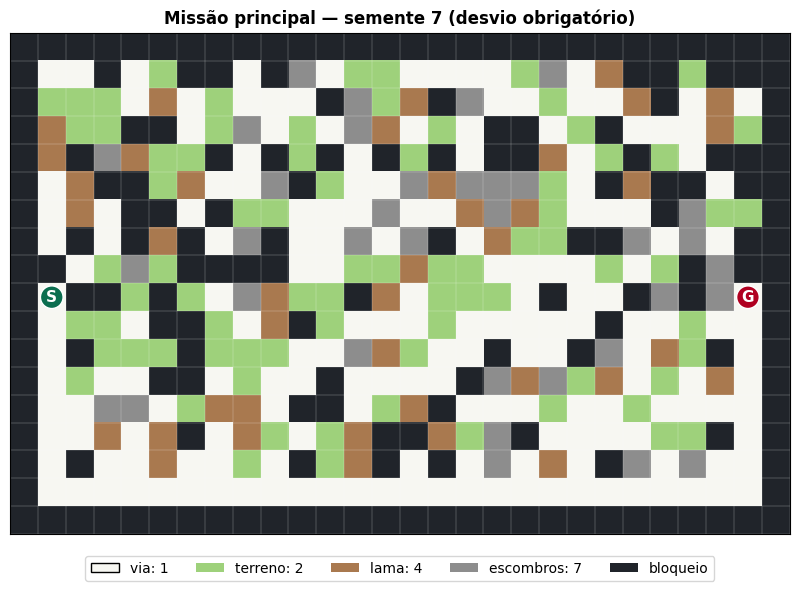

In [2]:
CUSTOS_TERRENO = {".": 1, "g": 2, "m": 4, "r": 7}
MOVIMENTOS = (
    ("N", (-1, 0)),
    ("L", (0, 1)),
    ("S", (1, 0)),
    ("O", (0, -1)),
)


@dataclass(frozen=True)
class ProblemaGrade:
    grade: Tuple[str, ...]
    inicial: Estado
    objetivo: Estado
    custos: Mapping[str, int] = field(
        default_factory=lambda: dict(CUSTOS_TERRENO),
        compare=False,
        repr=False,
    )

    def __post_init__(self):
        if not self.grade or len({len(linha) for linha in self.grade}) != 1:
            raise ValueError("A grade deve ser retangular e não vazia.")
        for estado in (self.inicial, self.objetivo):
            if not self.valido(estado):
                raise ValueError(f"Estado inválido ou bloqueado: {estado}")

    @property
    def linhas(self) -> int:
        return len(self.grade)

    @property
    def colunas(self) -> int:
        return len(self.grade[0])

    def valido(self, estado: Estado) -> bool:
        l, c = estado
        return (
            0 <= l < len(self.grade)
            and 0 <= c < len(self.grade[0])
            and self.grade[l][c] != "#"
        )

    def eh_objetivo(self, estado: Estado) -> bool:
        return estado == self.objetivo

    def sucessores(self, estado: Estado):
        l, c = estado
        saida = []
        for acao, (dl, dc) in MOVIMENTOS:
            proximo = (l + dl, c + dc)
            if self.valido(proximo):
                terreno = self.grade[proximo[0]][proximo[1]]
                saida.append((proximo, acao, self.custos[terreno]))
        return saida

    def heuristica(self, estado: Estado) -> float:
        l, c = estado
        lg, cg = self.objetivo
        menor_custo = min(self.custos.values())
        return (abs(l - lg) + abs(c - cg)) * menor_custo


def problema_de_texto(linhas: Sequence[str]) -> ProblemaGrade:
    """Converte um mapa textual com um único S e um único G."""
    if not linhas or len({len(linha) for linha in linhas}) != 1:
        raise ValueError("O mapa textual deve ser retangular.")
    inicio = objetivo = None
    grade = []
    for l, linha in enumerate(linhas):
        nova = list(linha)
        for c, simbolo in enumerate(nova):
            if simbolo == "S":
                if inicio is not None:
                    raise ValueError("O mapa possui mais de um S.")
                inicio = (l, c)
                nova[c] = "."
            elif simbolo == "G":
                if objetivo is not None:
                    raise ValueError("O mapa possui mais de um G.")
                objetivo = (l, c)
                nova[c] = "."
            elif simbolo not in set(CUSTOS_TERRENO) | {"#"}:
                raise ValueError(f"Símbolo desconhecido: {simbolo}")
        grade.append("".join(nova))
    if inicio is None or objetivo is None:
        raise ValueError("O mapa deve conter S e G.")
    return ProblemaGrade(tuple(grade), inicio, objetivo)


def gerar_cenario_benchmark(
    semente: int, linhas: int = 18, colunas: int = 28
) -> ProblemaGrade:
    """
    Gera um cenário solucionável e reproduzível.

    Sementes pares possuem corredor direto; sementes ímpares exigem que o
    robô inicialmente se afaste do objetivo. Isso cria casos fáceis e
    armadilhas controladas para a busca local.
    """
    if linhas < 7 or colunas < 9:
        raise ValueError("Use ao menos 7 linhas e 9 colunas.")
    rng = random.Random(semente)
    grade = [["#"] * colunas for _ in range(linhas)]
    terrenos = [".", ".", ".", "g", "g", "m", "r"]

    for l in range(1, linhas - 1):
        for c in range(1, colunas - 1):
            grade[l][c] = "#" if rng.random() < 0.22 else rng.choice(terrenos)

    meio = linhas // 2
    inicio = (meio, 1)
    objetivo = (meio, colunas - 2)

    if semente % 2 == 0:
        # Corredor monotônico: sempre existe um vizinho que reduz h.
        for c in range(1, colunas - 1):
            grade[meio][c] = "."
    else:
        # Desvio garantido pelo sul: o primeiro passo aumenta h.
        for l in range(meio, linhas - 1):
            grade[l][1] = "."
        for c in range(1, colunas - 1):
            grade[linhas - 2][c] = "."
        for l in range(meio, linhas - 1):
            grade[l][colunas - 2] = "."
        grade[meio][2] = "#"
        grade[meio - 1][1] = "#"

    grade[inicio[0]][inicio[1]] = "."
    grade[objetivo[0]][objetivo[1]] = "."
    return ProblemaGrade(tuple("".join(linha) for linha in grade), inicio, objetivo)


CORES = {
    "#": "#20242a",
    ".": "#f7f7f2",
    "g": "#9ed17b",
    "m": "#a9794f",
    "r": "#8d8d8d",
}


def mostrar_cenario(
    problema: ProblemaGrade,
    rota: Optional[Sequence[Estado]] = None,
    titulo: str = "Cenário",
    tamanho=(12, 6),
):
    ordem = ["#", ".", "g", "m", "r"]
    indice = {simbolo: i for i, simbolo in enumerate(ordem)}
    matriz = np.array([[indice[x] for x in linha] for linha in problema.grade])
    cmap = ListedColormap([CORES[x] for x in ordem])
    fig, ax = plt.subplots(figsize=tamanho)
    ax.imshow(matriz, cmap=cmap, vmin=-0.5, vmax=len(ordem) - 0.5)
    ax.set_xticks(np.arange(-0.5, problema.colunas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, problema.linhas, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.35, alpha=0.45)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    if rota:
        ys = [p[0] for p in rota]
        xs = [p[1] for p in rota]
        ax.plot(xs, ys, color="#1565c0", linewidth=3, alpha=0.9, zorder=3)

    for texto, estado, cor in (
        ("S", problema.inicial, "#0b6e4f"),
        ("G", problema.objetivo, "#b00020"),
    ):
        ax.text(
            estado[1], estado[0], texto, ha="center", va="center",
            color="white", fontweight="bold", fontsize=11,
            bbox=dict(boxstyle="circle,pad=0.25", facecolor=cor, edgecolor="white"),
            zorder=4,
        )

    legenda = [
        Patch(facecolor=CORES["."], edgecolor="black", label="via: 1"),
        Patch(facecolor=CORES["g"], label="terreno: 2"),
        Patch(facecolor=CORES["m"], label="lama: 4"),
        Patch(facecolor=CORES["r"], label="escombros: 7"),
        Patch(facecolor=CORES["#"], label="bloqueio"),
    ]
    ax.legend(handles=legenda, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.03))
    ax.set_title(titulo, fontweight="bold")
    plt.tight_layout()
    plt.show()


PROBLEMA_PRINCIPAL = gerar_cenario_benchmark(7)
mostrar_cenario(
    PROBLEMA_PRINCIPAL,
    titulo="Missão principal — semente 7 (desvio obrigatório)",
)


## 5. Contrato comum dos algoritmos

Todas as funções devem receber um `ProblemaGrade` e devolver um `ResultadoBusca`. Esse contrato torna a comparação justa. O maior tamanho da fronteira é usado como aproximação didática do consumo de memória.

**Convenção de métricas:** o estado inicial conta como gerado; um estado conta como expandido quando seus sucessores são examinados; o teste de objetivo ocorre quando o estado é selecionado para processamento.


In [3]:
@dataclass
class ResultadoBusca:
    algoritmo: str
    encontrou: bool
    rota: List[Estado]
    custo: float
    profundidade: Optional[int]
    expandidos: int
    gerados: int
    max_fronteira: int
    tempo_ms: float
    motivo: str = ""

    def resumo(self) -> Dict[str, object]:
        return {
            "algoritmo": self.algoritmo,
            "encontrou": self.encontrou,
            "custo": self.custo if self.encontrou else np.nan,
            "movimentos": self.profundidade,
            "expandidos": self.expandidos,
            "gerados": self.gerados,
            "max_fronteira": self.max_fronteira,
            "tempo_ms": self.tempo_ms,
            "motivo": self.motivo,
        }


def reconstruir_rota(pai: Mapping[Estado, Optional[Estado]], fim: Estado) -> List[Estado]:
    rota = []
    atual = fim
    while atual is not None:
        rota.append(atual)
        atual = pai[atual]
    return list(reversed(rota))


def custo_rota(problema: ProblemaGrade, rota: Sequence[Estado]) -> float:
    if not rota:
        return inf
    total = 0.0
    for estado in rota[1:]:
        terreno = problema.grade[estado[0]][estado[1]]
        total += problema.custos[terreno]
    return total


def validar_rota(problema: ProblemaGrade, rota: Sequence[Estado]) -> Tuple[bool, str]:
    if not rota:
        return False, "rota vazia"
    if rota[0] != problema.inicial:
        return False, "a rota não começa no estado inicial"
    if rota[-1] != problema.objetivo:
        return False, "a rota não termina no objetivo"
    for anterior, atual in zip(rota, rota[1:]):
        if not problema.valido(atual):
            return False, f"estado inválido: {atual}"
        distancia = abs(anterior[0] - atual[0]) + abs(anterior[1] - atual[1])
        if distancia != 1:
            return False, f"movimento não adjacente: {anterior} -> {atual}"
    return True, "ok"


def resultado_sucesso(
    algoritmo: str,
    problema: ProblemaGrade,
    rota: Sequence[Estado],
    expandidos: int,
    gerados: int,
    max_fronteira: int,
    inicio_t: float,
) -> ResultadoBusca:
    return ResultadoBusca(
        algoritmo=algoritmo,
        encontrou=True,
        rota=list(rota),
        custo=custo_rota(problema, rota),
        profundidade=len(rota) - 1,
        expandidos=expandidos,
        gerados=gerados,
        max_fronteira=max_fronteira,
        tempo_ms=(perf_counter() - inicio_t) * 1000,
        motivo="objetivo alcançado",
    )


def resultado_falha(
    algoritmo: str,
    expandidos: int,
    gerados: int,
    max_fronteira: int,
    inicio_t: float,
    motivo: str,
    rota_parcial: Optional[Sequence[Estado]] = None,
) -> ResultadoBusca:
    return ResultadoBusca(
        algoritmo=algoritmo,
        encontrou=False,
        rota=list(rota_parcial or []),
        custo=inf,
        profundidade=None,
        expandidos=expandidos,
        gerados=gerados,
        max_fronteira=max_fronteira,
        tempo_ms=(perf_counter() - inicio_t) * 1000,
        motivo=motivo,
    )


## 6. Implementação dos algoritmos


### 6.1 Busca em largura

Use uma fila FIFO. Em custos não uniformes, a garantia é de menor profundidade, não de menor custo.


In [ ]:
def busca_largura(problema: ProblemaGrade) -> ResultadoBusca:
        
    inicio_t = perf_counter()
    fronteira = deque([problema.inicial])
    pai = {problema.inicial: None}
    nos_descobertos = {problema.inicial}

    nos_expandidos = 0
    nos_gerados = 1
    max_fronteira = 1

    while fronteira:
        max_fronteira = max(max_fronteira, len(fronteira))
        estado_atual = fronteira.popleft()

        if problema.eh_objetivo(estado_atual):
            rota = reconstruir_rota(pai, estado_atual)
            return resultado_sucesso(
                "Busca em Largura",
                problema,
                rota,
                nos_expandidos,
                nos_gerados,
                max_fronteira,
                inicio_t,
            )

        nos_expandidos += 1
        for proximo, acao, custos in problema.sucessores(estado_atual):
            if proximo not in nos_descobertos:
                pai[proximo] = estado_atual
                nos_descobertos.add(proximo)
                fronteira.append(proximo)
                nos_gerados += 1

    return resultado_falha(
        "Busca em Largura",
        nos_expandidos,
        nos_gerados,
        max_fronteira,
        inicio_t,
        "fronteira esgotada",
    )

### 6.2 Busca em profundidade

Use uma pilha LIFO e controle estados repetidos. A ordem efetiva deve ser `N, L, S, O`.


In [ ]:
def busca_profundidade(problema: ProblemaGrade) -> ResultadoBusca:
    
    inicio_t = perf_counter()
    fronteira = [problema.inicial]
    pai = {problema.inicial: None}
    nos_descobertos = {problema.inicial}

    nos_expandidos = 0
    nos_gerados = 1
    max_fronteira = 1

    while fronteira:
        max_fronteira = max(max_fronteira, len(fronteira))
        estado_atual = fronteira.pop()

        if problema.eh_objetivo(estado_atual):
            rota = reconstruir_rota(pai, estado_atual)
            return resultado_sucesso(
                "Busca em Profundidade",
                problema,
                rota,
                nos_expandidos,
                nos_gerados,
                max_fronteira,
                inicio_t,
            )

        nos_expandidos += 1
        for proximo, acao, custos in reversed(problema.sucessores(estado_atual)):
            if proximo not in nos_descobertos:
                pai[proximo] = estado_atual
                nos_descobertos.add(proximo)
                fronteira.append(proximo)
                nos_gerados += 1
                
    return resultado_falha(
        "Busca em Profundidade",
        nos_expandidos,
        nos_gerados,
        max_fronteira,
        inicio_t,
        "fronteira esgotada",
    )

### 6.3 Busca de custo uniforme

Priorize o menor `g(n)`. Um estado pode receber um custo melhor antes de ser processado.


In [6]:
def busca_custo_uniforme(problema: ProblemaGrade) -> ResultadoBusca:

    inicio_t = perf_counter()
    fronteira = []
    heappush(fronteira, (0, problema.inicial))

    pai = {problema.inicial: None}
    visitados = {}

    nos_expandidos = 0
    nos_gerados = 1
    max_fronteira = 1

    while fronteira:
        max_fronteira = max(max_fronteira, len(fronteira))
        custo_atual, estado_atual = heappop(fronteira)

        if estado_atual in visitados and custo_atual > visitados[estado_atual]:
            continue

        if problema.eh_objetivo(estado_atual):
            rota = reconstruir_rota(pai, estado_atual)
            return resultado_sucesso(
                "Busca de Custo Uniforme",
                problema,
                rota,
                nos_expandidos,
                nos_gerados,
                max_fronteira,
                inicio_t,
            )

        visitados[estado_atual] = custo_atual
        nos_expandidos += 1

        for proximo, acao, custo in problema.sucessores(estado_atual):
            novo_custo = custo_atual + custo
            if proximo not in visitados or novo_custo < visitados[proximo]:
                pai[proximo] = estado_atual
                heappush(fronteira, (novo_custo, proximo))
                nos_gerados += 1
                
    return resultado_falha(
        "Busca de Custo Uniforme",
        nos_expandidos,
        nos_gerados,
        max_fronteira,
        inicio_t,
        "fronteira esgotada",
    )

### 6.4 Aprofundamento limitado

Não expanda nós na profundidade `L`. Distinga **corte** de falha por esgotamento da fronteira.


In [ ]:
def busca_aprofundamento_limitado(
    problema: ProblemaGrade, limite: int
) -> ResultadoBusca:
    
    inicio_t = perf_counter()
    fronteira = {(problema.inicial, 0)}  # Armazena tuplas de (estado, profundidade)
    pai = {problema.inicial: None}
    nos_descobertos = {problema.inicial}

    nos_expandidos = 0
    nos_gerados = 1
    max_fronteira = 1
    flag_corte = False  # Indica se houve corte por limite de profundidade

    while fronteira:
        max_fronteira = max(max_fronteira, len(fronteira))
        estado_atual, profundidade_atual = fronteira.pop()

        if problema.eh_objetivo(estado_atual):
            rota = reconstruir_rota(pai, estado_atual)
            return resultado_sucesso(
                "Busca em Profundidade Limitada",
                problema,
                rota,
                nos_expandidos,
                nos_gerados,
                max_fronteira,
                inicio_t,
            )

        if profundidade_atual == limite:
            flag_corte = True
            continue

        nos_expandidos += 1
        for proximo, acao, custos in reversed(problema.sucessores(estado_atual)):
            if proximo not in nos_descobertos:
                pai[proximo] = estado_atual
                nos_descobertos.add(proximo)
                fronteira.append((proximo, profundidade_atual + 1))
                nos_gerados += 1
                
    return resultado_falha(
        "Busca em Profundidade Limitada",
        nos_expandidos,
        nos_gerados,
        max_fronteira,
        inicio_t,
        "fronteira esgotada" if not flag_corte else "corte por limite de profundidade"
    )

### 6.5 Busca gulosa

Priorize somente `h(n)`. A fronteira global diferencia esta estratégia da subida da encosta.


In [ ]:
def busca_gulosa(problema: ProblemaGrade) -> ResultadoBusca:
    inicio_t = perf_counter()
    fronteira = []
    heappush(fronteira, (problema.heuristica(problema.inicial), problema.inicial))
    #heuristica recebe um estado (posição) e retorna o produto da distância até o estado final vezes o menor custo do mapa
    #Então a fronteira fica ordenada de acordo com a distância do objetivo, priorizando os que se aproximam

    pai = {problema.inicial: None}
    visitados = set()

    nos_expandidos = 0
    nos_gerados = 1
    max_fronteira = 1

    while fronteira:
        max_fronteira = max(max_fronteira, len(fronteira))
        valor_heuristico, estado_atual = heappop(fronteira)

        if estado_atual in visitados:
            continue

        visitados.add(estado_atual)

        if problema.eh_objetivo(estado_atual):
            rota = reconstruir_rota(pai, estado_atual)
            return resultado_sucesso(
                "Busca Gulosa",
                problema,
                rota,
                nos_expandidos,
                nos_gerados,
                max_fronteira,
                inicio_t,
            )

        nos_expandidos += 1

        for proximo, acao, custos in problema.sucessores(estado_atual):
            if proximo not in visitados:
                pai[proximo] = estado_atual
                heappush(fronteira, (problema.heuristica(proximo), proximo))
                nos_gerados += 1
                
    return resultado_falha(
        "Busca Gulosa",
        nos_expandidos,
        nos_gerados,
        max_fronteira,
        inicio_t,
        "fronteira esgotada",
    )

### 6.6 Busca A*

Priorize `f(n)=g(n)+h(n)`. Registre o melhor `g` conhecido e atualize o pai quando ele melhorar.


In [ ]:
def busca_a_estrela(problema: ProblemaGrade) -> ResultadoBusca:

    inicio_t = perf_counter()
    fronteira = []
    heappush(fronteira, (problema.heuristica(problema.inicial), problema.inicial))

    pai = {problema.inicial: None}
    visitados = set()
    custo_acumulado = {problema.inicial: 0}

    nos_expandidos = 0
    nos_gerados = 1
    max_fronteira = 1

    while fronteira:
        max_fronteira = max(max_fronteira, len(fronteira))
        valor_heuristico, estado_atual = heappop(fronteira)

        if estado_atual in visitados:
            continue

        if problema.eh_objetivo(estado_atual):
            rota = reconstruir_rota(pai, estado_atual)
            return resultado_sucesso(
                "Busca A*",
                problema,
                rota,
                nos_expandidos,
                nos_gerados,
                max_fronteira,
                inicio_t,
            )

        visitados.add(estado_atual)
        nos_expandidos += 1

        for proximo, acao, custo in problema.sucessores(estado_atual):
            novo_custo = custo_acumulado[estado_atual] + custo
            if proximo not in visitados or novo_custo < custo_acumulado[proximo]:
                custo_acumulado[proximo] = novo_custo
                pai[proximo] = estado_atual
                f = novo_custo + problema.heuristica(proximo)
                heappush(fronteira, (f, proximo))
                nos_gerados += 1
                
    return resultado_falha(
        "Busca A*",
        nos_expandidos,
        nos_gerados,
        max_fronteira,
        inicio_t,
        "fronteira esgotada",
    )


### 6.7 Busca local por subida da encosta

Use `-h(n)` como valor local: aceite apenas um vizinho com `h` estritamente menor, sem fronteira global nem retrocesso.


In [ ]:
def busca_local_subida_encosta(problema: ProblemaGrade) -> ResultadoBusca:

    inicio_t = perf_counter()
    estado_atual = problema.inicial
    rota = [estado_atual]

    nos_expandidos = 0
    nos_gerados = 1
    max_fronteira = 1

    while True:
        if problema.eh_objetivo(estado_atual):
            return resultado_sucesso(
                "Subida de Encosta",
                problema,
                rota,
                nos_expandidos,
                nos_gerados,
                max_fronteira,
                inicio_t,
            )
        
        vizinhos = problema.sucessores(estado_atual)
        max_fronteira = max(max_fronteira, len(vizinhos))
        nos_expandidos += 1
        nos_gerados += len(vizinhos)

        melhor_vizinho = None
        heuristica_atual = problema.heuristica(estado_atual)
        melhor_heuristica = heuristica_atual

        for proximo, acao, custo in vizinhos:
            heuristica_proximo = problema.heuristica(proximo)
            if heuristica_proximo < melhor_heuristica:
                melhor_heuristica = heuristica_proximo
                melhor_vizinho = proximo
            elif heuristica_proximo == heuristica_atual:
                return resultado_falha(
                    "Subida de Encosta",
                    nos_expandidos,
                    nos_gerados,
                    max_fronteira,
                    inicio_t,
                    "preso em um platô",
                    rota_parcial=rota,
                )

        if melhor_vizinho is None:
            return resultado_falha(
                "Subida de Encosta",
                nos_expandidos,
                nos_gerados,
                max_fronteira,
                inicio_t,
                "preso em um mínimo local",
                rota_parcial=rota,
            )
        estado_atual = melhor_vizinho
        rota.append(estado_atual)

## 7. Registro comum das estratégias

O dicionário abaixo permite executar todas as abordagens sob o mesmo protocolo. O limite inicial da busca limitada é `L=60`.


In [ ]:
LIMITE_PADRAO = 60
ALGORITMOS: Dict[str, Callable[[ProblemaGrade], ResultadoBusca]] = {
    "Largura": busca_largura,
    "Profundidade": busca_profundidade,
    "Custo uniforme": busca_custo_uniforme,
    "Aprof. limitado": lambda p: busca_aprofundamento_limitado(p, LIMITE_PADRAO),
    "Gulosa": busca_gulosa,
    "A*": busca_a_estrela,
    "Local": busca_local_subida_encosta,
}
print(f"{len(ALGORITMOS)} estratégias registradas.")


7 estratégias registradas.


## 8. Testes automáticos de corretude

Os testes usam casos pequenos com comportamento conhecido:

1. **corredor simples:** todas as estratégias devem encontrar a solução de custo 4;
2. **rota curta e cara:** largura encontra 4 movimentos com custo 22; custo uniforme e A* devem encontrar 6 movimentos com custo 6;
3. **barreira heurística:** existe solução, mas a subida da encosta para quando seria necessário afastar-se temporariamente do objetivo;
4. **limite:** `L=3` deve cortar uma solução de profundidade 4; `L=4` deve encontrá-la.

Não modifique esta seção para fazer uma implementação incorreta passar.


In [ ]:
TESTE_SIMPLES = problema_de_texto([
    "#######",
    "#S...G#",
    "#######",
])

TESTE_CUSTO = problema_de_texto([
    "#######",
    "#SrrrG#",
    "#.....#",
    "#######",
])

TESTE_ARMADILHA = problema_de_texto([
    "#########",
    "#S..#..G#",
    "#...#...#",
    "#.......#",
    "#########",
])


def testar_corretude() -> pd.DataFrame:
    registros = []

    def verificar(nome, funcao):
        try:
            funcao()
            registros.append({"teste": nome, "aprovado": True, "detalhe": "ok"})
        except Exception as erro:
            registros.append({
                "teste": nome,
                "aprovado": False,
                "detalhe": f"{type(erro).__name__}: {erro}",
            })

    def todas_no_corredor():
        for nome, algoritmo in ALGORITMOS.items():
            resultado = algoritmo(TESTE_SIMPLES)
            assert resultado.encontrou, f"{nome} não encontrou o corredor simples"
            valida, mensagem = validar_rota(TESTE_SIMPLES, resultado.rota)
            assert valida, f"{nome}: {mensagem}"
            assert resultado.profundidade == 4, f"{nome}: profundidade incorreta"
            assert isclose(resultado.custo, 4.0), f"{nome}: custo incorreto"
            assert resultado.gerados >= 1 and resultado.expandidos >= 0
            assert resultado.max_fronteira >= 1 and resultado.tempo_ms >= 0

    def largura_minimiza_passos_nao_custo():
        resultado = busca_largura(TESTE_CUSTO)
        assert resultado.encontrou
        assert resultado.profundidade == 4
        assert isclose(resultado.custo, 22.0)

    def custo_uniforme_otimo():
        resultado = busca_custo_uniforme(TESTE_CUSTO)
        assert resultado.encontrou
        assert resultado.profundidade == 6
        assert isclose(resultado.custo, 6.0)

    def a_estrela_otimo():
        resultado = busca_a_estrela(TESTE_CUSTO)
        assert resultado.encontrou
        assert resultado.profundidade == 6
        assert isclose(resultado.custo, 6.0)

    def limitada_respeita_limite():
        corte = busca_aprofundamento_limitado(TESTE_SIMPLES, limite=3)
        sucesso = busca_aprofundamento_limitado(TESTE_SIMPLES, limite=4)
        assert not corte.encontrou and "corte" in corte.motivo
        assert sucesso.encontrou and sucesso.profundidade == 4

    def buscas_globais_superam_barreira():
        funcoes = [
            busca_largura,
            busca_profundidade,
            busca_custo_uniforme,
            lambda p: busca_aprofundamento_limitado(p, 10),
            busca_gulosa,
            busca_a_estrela,
        ]
        for funcao in funcoes:
            resultado = funcao(TESTE_ARMADILHA)
            assert resultado.encontrou, funcao.__name__
            assert validar_rota(TESTE_ARMADILHA, resultado.rota)[0]

    def local_reconhece_armadilha():
        resultado = busca_local_subida_encosta(TESTE_ARMADILHA)
        assert not resultado.encontrou
        assert "mínimo local" in resultado.motivo or "platô" in resultado.motivo
        assert resultado.rota, "a rota parcial deve ser preservada"

    verificar("Todas resolvem o corredor simples", todas_no_corredor)
    verificar("Largura minimiza passos, não custo", largura_minimiza_passos_nao_custo)
    verificar("Custo uniforme encontra custo 6", custo_uniforme_otimo)
    verificar("A* encontra custo 6", a_estrela_otimo)
    verificar("Aprofundamento respeita L", limitada_respeita_limite)
    verificar("Buscas globais contornam barreira", buscas_globais_superam_barreira)
    verificar("Busca local identifica armadilha", local_reconhece_armadilha)

    tabela = pd.DataFrame(registros)
    aprovados = int(tabela["aprovado"].sum())
    print(f"Testes aprovados: {aprovados}/{len(tabela)}")
    return tabela


RELATORIO_TESTES = testar_corretude()
display(RELATORIO_TESTES)


Testes aprovados: 0/7


,teste,aprovado,detalhe
0,Todas resolvem o corredor simples,False,NotImplementedError: Implemente busca_largura
1,"Largura minimiza passos, não custo",False,NotImplementedError: Implemente busca_largura
2,Custo uniforme encontra custo 6,False,NotImplementedError: Implemente busca_custo_un...
3,A* encontra custo 6,False,NotImplementedError: Implemente busca_a_estrela
4,Aprofundamento respeita L,False,NotImplementedError: Implemente busca_aprofund...
5,Buscas globais contornam barreira,False,NotImplementedError: Implemente busca_largura
6,Busca local identifica armadilha,False,NotImplementedError: Implemente busca_local_su...


### Inspeção visual dos casos diagnósticos

Depois que os testes passarem, compare as rotas. Observe que uma rota com menos movimentos pode custar mais e que a busca local preserva apenas uma rota parcial quando fica presa.


In [ ]:
if RELATORIO_TESTES["aprovado"].all():
    largura_cara = busca_largura(TESTE_CUSTO)
    a_estrela_barata = busca_a_estrela(TESTE_CUSTO)
    local_presa = busca_local_subida_encosta(TESTE_ARMADILHA)

    mostrar_cenario(
        TESTE_CUSTO, largura_cara.rota,
        f"Largura: {largura_cara.profundidade} movimentos; custo {largura_cara.custo:.0f}",
        tamanho=(8, 3),
    )
    mostrar_cenario(
        TESTE_CUSTO, a_estrela_barata.rota,
        f"A*: {a_estrela_barata.profundidade} movimentos; custo {a_estrela_barata.custo:.0f}",
        tamanho=(8, 3),
    )
    mostrar_cenario(
        TESTE_ARMADILHA, local_presa.rota,
        f"Busca local: {local_presa.motivo}",
        tamanho=(8, 4),
    )
else:
    print("Complete as implementações e aprove todos os testes para visualizar as rotas.")


Complete as implementações e aprove todos os testes para visualizar as rotas.


## 9. Experimento principal

Serão usados 30 cenários (`sementes 0..29`). Sementes pares têm uma passagem direta; sementes ímpares obrigam um primeiro movimento que aumenta `h`. Todos os cenários possuem solução por construção.

Cada par algoritmo–cenário é executado três vezes; a mediana do tempo reduz parte do ruído. As demais métricas são coletadas da primeira execução, pois as estratégias são determinísticas sob as convenções desta prática.


In [ ]:
def executar_benchmark(
    algoritmos: Mapping[str, Callable[[ProblemaGrade], ResultadoBusca]],
    sementes=range(30),
    repeticoes_tempo: int = 3,
) -> pd.DataFrame:
    registros = []
    for semente in sementes:
        problema = gerar_cenario_benchmark(semente)
        for nome, algoritmo in algoritmos.items():
            execucoes = [algoritmo(problema) for _ in range(repeticoes_tempo)]
            referencia = execucoes[0]
            if referencia.encontrou:
                valida, mensagem = validar_rota(problema, referencia.rota)
                if not valida:
                    raise AssertionError(f"{nome}, semente {semente}: {mensagem}")
            # Como tudo é determinístico, resultados lógicos devem coincidir.
            assinatura = [
                (r.encontrou, r.custo, r.profundidade, tuple(r.rota))
                for r in execucoes
            ]
            if len(set(assinatura)) != 1:
                raise AssertionError(f"Resultado não determinístico: {nome}, semente {semente}")

            registros.append({
                "semente": semente,
                "tipo_cenario": "direto" if semente % 2 == 0 else "desvio obrigatório",
                "algoritmo": nome,
                "encontrou": referencia.encontrou,
                "custo": referencia.custo if referencia.encontrou else np.nan,
                "movimentos": referencia.profundidade,
                "expandidos": referencia.expandidos,
                "gerados": referencia.gerados,
                "max_fronteira": referencia.max_fronteira,
                "tempo_ms": median(r.tempo_ms for r in execucoes),
                "motivo": referencia.motivo,
            })
    return pd.DataFrame(registros)


def resumir_benchmark(df: pd.DataFrame) -> pd.DataFrame:
    resumo = (
        df.groupby("algoritmo", sort=False)
        .agg(
            taxa_sucesso=("encontrou", lambda x: 100 * x.mean()),
            custo_medio=("custo", "mean"),
            movimentos_medianos=("movimentos", "median"),
            expandidos_medianos=("expandidos", "median"),
            gerados_medianos=("gerados", "median"),
            fronteira_mediana=("max_fronteira", "median"),
            tempo_mediano_ms=("tempo_ms", "median"),
        )
        .reset_index()
    )
    return resumo.round(3)


if RELATORIO_TESTES["aprovado"].all():
    RESULTADOS_BRUTOS = executar_benchmark(ALGORITMOS)
    RESUMO = resumir_benchmark(RESULTADOS_BRUTOS)
    display(RESUMO)
else:
    RESULTADOS_BRUTOS = pd.DataFrame()
    RESUMO = pd.DataFrame()
    print("Benchmark bloqueado: aprove todos os testes de corretude primeiro.")


Benchmark bloqueado: aprove todos os testes de corretude primeiro.


In [ ]:
if not RESUMO.empty:
    ordem = list(ALGORITMOS)
    plot = RESUMO.set_index("algoritmo").reindex(ordem)
    fig, eixos = plt.subplots(2, 2, figsize=(14, 9))

    plot["taxa_sucesso"].plot.bar(ax=eixos[0, 0], color="#2a9d8f")
    eixos[0, 0].set_title("Taxa de sucesso nos 30 cenários")
    eixos[0, 0].set_ylabel("Sucesso (%)")
    eixos[0, 0].set_ylim(0, 105)

    plot["custo_medio"].plot.bar(ax=eixos[0, 1], color="#e9c46a")
    eixos[0, 1].set_title("Custo médio das soluções encontradas")
    eixos[0, 1].set_ylabel("Custo")

    plot["expandidos_medianos"].plot.bar(ax=eixos[1, 0], color="#f4a261")
    eixos[1, 0].set_title("Nós expandidos — mediana")
    eixos[1, 0].set_ylabel("Nós")

    plot["tempo_mediano_ms"].plot.bar(ax=eixos[1, 1], color="#457b9d")
    eixos[1, 1].set_title("Tempo — mediana das execuções")
    eixos[1, 1].set_ylabel("ms")

    for ax in eixos.flat:
        ax.grid(axis="y", alpha=0.25)
        ax.tick_params(axis="x", rotation=35)
    fig.suptitle("Comparação das estratégias de busca", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 10. Análise de uma missão específica

Use a missão principal (semente 7) para inspecionar rotas e explicar por que as estratégias tomam decisões diferentes.


In [ ]:
if RELATORIO_TESTES["aprovado"].all():
    resultados_missao = {nome: algoritmo(PROBLEMA_PRINCIPAL) for nome, algoritmo in ALGORITMOS.items()}
    display(pd.DataFrame([r.resumo() for r in resultados_missao.values()]))
    for nome in ("Largura", "Custo uniforme", "Gulosa", "A*", "Local"):
        r = resultados_missao[nome]
        mostrar_cenario(
            PROBLEMA_PRINCIPAL,
            r.rota,
            f"{nome} — " + (
                f"custo {r.custo:.0f}; {r.profundidade} movimentos"
                if r.encontrou else f"falhou: {r.motivo}"
            ),
        )


## 11. Relatório do estudante — complete em Markdown

### 11.1 Detalhamento do problema

Descreva, com suas palavras, estados, ações, transições, objetivo, custo e heurística. Explique por que a heurística não superestima o custo restante.

**Resposta:** _TODO_

### 11.2 Protocolo experimental

Registre versões do ambiente, sementes, repetições, ordem dos sucessores, limite de profundidade e qualquer decisão de implementação que afete a comparação.

**Resposta:** _TODO_

### 11.3 Resultados e comparação crítica

Inclua a tabela-resumo e responda:

1. Qual estratégia encontrou o menor custo? Isso coincide com a menor quantidade de movimentos?
2. Como a heurística alterou nós expandidos e fronteira?
3. Em quais cenários a busca local falhou? Por que isso não significa que o objetivo era inalcançável?
4. O limite `L=60` foi adequado? Mostre evidência e discuta um limite insuficiente.
5. Tempo isoladamente é uma medida confiável neste experimento? Relacione-o a expansões e ao ambiente de execução.

**Resposta:** _TODO_

### 11.4 Conclusão

Indique a estratégia mais adequada **para este problema e para os critérios definidos**, justificando com pelo menos três métricas. Discuta uma condição sob a qual sua escolha poderia mudar.

**Resposta:** _TODO_


## 12. Checklist de entrega

- [ ] Os sete algoritmos foram implementados sem alterar o contrato fornecido.
- [ ] Os 7 testes automáticos foram aprovados.
- [ ] Os 30 cenários foram executados com as sementes indicadas.
- [ ] A tabela e os gráficos estão visíveis no notebook.
- [ ] O relatório foi preenchido em Markdown e interpreta as métricas.
- [ ] Todas as células foram executadas em ordem e os resultados foram preservados.
- [ ] O arquivo foi compartilhado conforme a orientação do professor.
